In [73]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


In [74]:
# since there is no external GPU on my machine, it does not show up 
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [75]:
dataset = tf.keras.datasets.cifar10.load_data()

In [76]:
(X_train, y_train), (X_test, y_test) = dataset

In [77]:
X_train.shape
# 50000 images of 32x32 pixels with a depth of 3 ---> RGB

(50000, 32, 32, 3)

In [78]:
y_train.shape

(50000, 1)

In [79]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]


In [80]:
def plot_sample(idx):
    plt.imshow(X_train[idx])
    print("Label: {}".format(classes[y_train[idx][0]]))

Label: frog


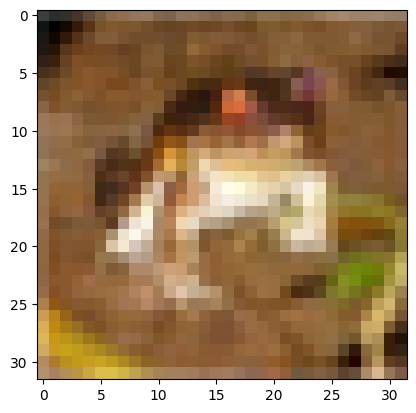

In [81]:
plot_sample(0)

Label: automobile


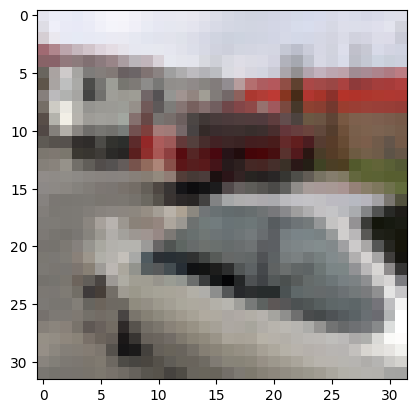

In [82]:
plot_sample(-1)

In [83]:
### Presprocessing --> Data Scaling

X_train_scaled = X_train / 255
X_test_scaled = X_test / 255


In [84]:
### One hot encoding the categorical variables.

y_train_categorical = keras.utils.to_categorical(y_train, num_classes=10)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=10)

In [85]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [86]:
y_train_categorical[:5] # one hot encoded binary column for each class with 1 assigned to category which the image belongs to

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [87]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),  # input layer ---> feature vector
    keras.layers.Dense(3000, activation='relu'),  # hidden layer for feature extraction
    keras.layers.Dense(1000, activation='relu'),  # hidden layer for feature extraction
    keras.layers.Dense(10, activation='sigmoid'), # output layer - 10 classes - 10 neurons
])

model.compile(
    optimizer='SGD',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_scaled, y_train_categorical, epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.3556 - loss: 1.8112


In [88]:
model.predict(X_test_scaled)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([0.3623595 , 0.5028398 , 0.67644095, 0.85017365, 0.35795236,
       0.7693459 , 0.8108735 , 0.08973554, 0.46352383, 0.09262054],
      dtype=float32)

In [89]:
# argmax returns the max of the returned probability vals
np.argmax(model.predict(X_test_scaled)[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


np.int64(3)

In [90]:
y_test[0]

array([3], dtype=uint8)

In [91]:
def get_model():
    model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000, activation='relu'),
    keras.layers.Dense(1000, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid'),
    ])

    model.compile(
        optimizer='SGD',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [92]:
%%timeit -n1 -r1
# timeit magic --> jupyter nb ---> time for execution of 1 cell
#              --> arguments are to ensure time calc for single run instead of average over multiple runs
with tf.device('/CPU:0'):
    selected_model = model
    model.fit(X_train_scaled, y_train_categorical, epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.4224 - loss: 1.6238
32.1 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [93]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    selected_model = model
    model.fit(X_train_scaled, y_train_categorical, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.4561 - loss: 1.5396
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.4791 - loss: 1.4805
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.4965 - loss: 1.4321
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5130 - loss: 1.3881
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5251 - loss: 1.3487
2min 47s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [94]:
### GPUs will be faster for sure.